# Epileptic Seizure Prediction Using EEG Data
## Investigating Preprocessing, Regularization, and Class Imbalance Handling
### Semester Major Assignment — IEEE Research Style

---
**Research Question:** *How do preprocessing choices and regularization strategies influence seizure prediction performance and overfitting/underfitting behavior?*

---

## Chapter 1 — Introduction

Epilepsy is a neurological disorder characterized by recurrent, unprovoked seizures affecting approximately 50 million people worldwide. Early and accurate seizure prediction using EEG (Electroencephalogram) signals has the potential to significantly improve patient quality of life by enabling timely interventions.

This project investigates how **preprocessing pipelines**, **regularization strategies** (L1, L2, Elastic Net), and **class imbalance handling** affect Logistic Regression generalization performance on three distinct EEG/epilepsy datasets. The study is structured as a small research paper with multiple experiments, visual comparisons, and quantitative analysis.

In [1]:
!pip install scikit-learn imbalanced-learn matplotlib seaborn pandas numpy

## Step 0 — Install & Import Dependencies

In [2]:
# Install required libraries (uncomment if running fresh in Colab)
# !pip install imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, learning_curve, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, average_precision_score,
    roc_auc_score, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import time

# Plotting style
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
COLORS = ['#2196F3','#4CAF50','#FF5722','#9C27B0','#FF9800']
print('All libraries loaded successfully.')

All libraries loaded successfully.


## Chapter 2 — Dataset Collection & Analysis

We use **three EEG/epilepsy datasets**, each with different characteristics:

### 2.1 — Upload Your Datasets

In Google Colab, upload these three files:
- `newfeature.csv` — EEG statistical features (200 samples, balanced)
- `For_Testing_EEG_FREE_FEATURE_Epilepsy_Dataset_csv.csv` — Clinical epilepsy dataset (4500 samples)
- `Epileptic_Seizure_Recognition.csv` — UCI raw EEG time-series (11500 samples)

**Run the cell below to upload them interactively:**

In [7]:
import os
import shutil

# ============================================================
# OPTION A: Assume files are already uploaded and rename them
# ============================================================
print('Assuming files are already uploaded in the /content/ directory.')

# Expected file names by the load_data cell
expected_df1_name = 'newfeature.csv'
expected_df2_name = 'For_Testing_EEG_FREE_FEATURE_Epilepsy_Dataset.csv'
expected_df3_name = 'Epileptic Seizure Recognition.csv'

# Original names from upload or current files in /content/
actual_df1_name_option1 = 'newfeature (1).csv' # If user uploaded multiple times
actual_df1_name_option2 = 'newfeature.csv'
actual_df2_name = 'For_Testing_EEG_FREE_FEATURE_Epilepsy_Dataset.csv.csv' # Note the extra .csv
actual_df3_name = 'Epileptic Seizure Recognition.csv'

# Rename files if necessary to match expected names
def rename_if_exists(old_name, new_name):
    if os.path.exists(old_name) and not os.path.exists(new_name):
        shutil.copy(old_name, new_name)
        print(f'Copied "{old_name}" to "{new_name}"')
    elif os.path.exists(old_name) and os.path.exists(new_name):
        print(f'"{new_name}" already exists.')
    elif not os.path.exists(old_name):
        print(f'Warning: "{old_name}" not found. Please ensure correct file is uploaded.')

# Handle newfeature.csv (might be newfeature.csv or newfeature (1).csv)
if os.path.exists(actual_df1_name_option1) and not os.path.exists(expected_df1_name):
    rename_if_exists(actual_df1_name_option1, expected_df1_name)
elif os.path.exists(actual_df1_name_option2) and not os.path.exists(expected_df1_name):
    # This case handles if newfeature.csv was uploaded correctly initially
    print(f'"{expected_df1_name}" already exists.')
else:
    print(f'Warning: "{expected_df1_name}" or "{actual_df1_name_option1}" not found. Please ensure correct file is uploaded.')

# Handle For_Testing_EEG_FREE_FEATURE_Epilepsy_Dataset.csv
rename_if_exists(actual_df2_name, expected_df2_name)

# Handle Epileptic Seizure Recognition.csv
if os.path.exists(expected_df3_name):
    print(f'"{expected_df3_name}" already exists.')
else:
    print(f'Warning: "{expected_df3_name}" not found. Please ensure correct file is uploaded.')

print('File readiness check complete.')


Assuming files are already uploaded in the /content/ directory.
Copied "For_Testing_EEG_FREE_FEATURE_Epilepsy_Dataset.csv.csv" to "For_Testing_EEG_FREE_FEATURE_Epilepsy_Dataset.csv"
"Epileptic Seizure Recognition.csv" already exists.
File readiness check complete.


In [8]:
# ============================================================
# Load the three datasets
# ============================================================
df1 = pd.read_csv('newfeature.csv')
df2 = pd.read_csv('For_Testing_EEG_FREE_FEATURE_Epilepsy_Dataset.csv')
df3 = pd.read_csv('Epileptic Seizure Recognition.csv')

print('Dataset 1 (EEG Features):', df1.shape)
print('Dataset 2 (Clinical):', df2.shape)
print('Dataset 3 (UCI EEG):', df3.shape)

Dataset 1 (EEG Features): (200, 12)
Dataset 2 (Clinical): (4500, 34)
Dataset 3 (UCI EEG): (11500, 180)


### 2.2 — Dataset Exploration

In [9]:
# ============================================================
# Dataset 1: EEG Statistical Features (newfeature.csv)
# ============================================================
print('='*60)
print('DATASET 1 — EEG Statistical Features')
print('='*60)
print(f'Samples: {df1.shape[0]}, Features: {df1.shape[1]-1}')
print(f'Target column: class')
print('\nClass distribution:')
print(df1['class'].value_counts())
print('\nFeature types: Extracted statistical features (min, max, mean, std, rms, etc.)')
print('\nFirst 3 rows:')
display(df1.head(3))
print('\nStatistical summary:')
display(df1.describe())

DATASET 1 — EEG Statistical Features
Samples: 200, Features: 11
Target column: class

Class distribution:
class
Healthy    100
Seizure    100
Name: count, dtype: int64

Feature types: Extracted statistical features (min, max, mean, std, rms, etc.)

First 3 rows:


,minimum,maximum,mean,standardDev,rms,zcf,variance,median,kurtosis,skewness,shanonEnt,class
0,-164,225,5.156944,50.530802,50.793268,478,2553.985372,4,0.609256,0.151829,5.285170,Healthy
1,-287,285,5.906029,91.432308,91.622858,539,8361.907915,4,-0.280578,0.004896,5.866593,Healthy
2,-295,360,-18.009519,104.215081,105.759756,536,10863.434720,-16,-0.350673,0.072243,5.985198,Healthy



Statistical summary:


,minimum,maximum,mean,standardDev,rms,zcf,variance,median,kurtosis,skewness,shanonEnt
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,-587.020000,562.100000,-8.631103,183.835905,188.710109,411.830000,59875.143813,-3.205000,0.323267,-0.001095,6.066201
std,509.896343,469.763407,29.182235,161.851378,159.051413,148.565303,90579.348575,62.413623,0.869958,0.547590,0.726504
min,-1885.000000,31.000000,-76.294118,29.810028,36.803935,20.000000,888.854697,-185.000000,-1.042537,-1.580058,4.783544
25%,-834.000000,211.000000,-19.378265,57.708264,66.049127,298.250000,3331.068302,-38.000000,-0.107032,-0.142502,5.416299
50%,-347.500000,327.500000,-5.379912,104.718250,109.418792,393.000000,10968.842420,-5.000000,0.225681,0.048637,5.947233
75%,-216.500000,793.000000,6.135099,274.561434,277.302511,533.500000,75410.154973,11.250000,0.589387,0.217917,6.771712
max,-84.000000,2047.000000,57.419331,612.550506,612.559815,738.000000,375309.728600,210.000000,6.798257,2.267679,7.373162


In [10]:
# ============================================================
# Dataset 2: Clinical Epilepsy Dataset
# ============================================================
print('='*60)
print('DATASET 2 — Clinical Epilepsy Dataset')
print('='*60)
print(f'Samples: {df2.shape[0]}, Features: {df2.shape[1]-1}')
print(f'Target column: Target/Epilepsy Type')
print('\nClass distribution:')
print(df2['Target/Epilepsy Type'].value_counts())
print('\nFeature types: Clinical/demographic features (age, gender, symptoms, medical history)')
print('\nFirst 3 rows:')
display(df2.head(3))

DATASET 2 — Clinical Epilepsy Dataset
Samples: 4500, Features: 33
Target column: Target/Epilepsy Type

Class distribution:
Target/Epilepsy Type
Focal Epilepsy          1401
No_Epilepsy             1331
Generalized Epilepsy    1138
Structural Epilepsy      433
Unknown Epilepsy         197
Name: count, dtype: int64

Feature types: Clinical/demographic features (age, gender, symptoms, medical history)

First 3 rows:


,Age,Gender,Weight,Height,Seizure Frequency,Seizure Duration,Seizure Onset Type,Aura Before Seizure,Loss of Consciousness,Muscle Stiffness,...,Genetic Disorder,Developmental Delay (in Children),Birth Complications,CNS Infection History,Medication Status,Alcohol or Drug Use,Drug Resistant Seizure History,MRI/CT Scan Result,Structural Brain Abnormality Detected,Target/Epilepsy Type
0,15,Male,48.3,168.2,0,30,Gradual,No,Yes,No,...,No,No,No,Yes,On Medication,No,Yes,Not Done,No,No_Epilepsy
1,4,Female,56.0,174.5,0,60,Sudden,Yes,Yes,No,...,Yes,No,No,No,Not on Medication,No,No,Abnormal,Yes,No_Epilepsy
2,36,Male,73.7,173.9,2,90,Sudden,Yes,No,No,...,No,No,Yes,No,On Medication,No,No,Abnormal,Yes,Focal Epilepsy


In [11]:
# ============================================================
# Dataset 3: UCI Epileptic Seizure Recognition
# ============================================================
print('='*60)
print('DATASET 3 — UCI Epileptic Seizure Recognition (Raw EEG)')
print('='*60)
print(f'Samples: {df3.shape[0]}, Features: {df3.shape[1]-1}')
print(f'Target column: y')
print('\nOriginal class distribution (5 classes):')
print(df3['y'].value_counts())
print('\nClass meanings:')
print('  1 = Seizure activity')
print('  2-5 = Non-seizure (different brain states)')
print('\nFeature types: Raw EEG time-series data (178 time points per segment)')
print('\nFirst row sample (first 10 features):')
display(df3.iloc[:2, :11])

DATASET 3 — UCI Epileptic Seizure Recognition (Raw EEG)
Samples: 11500, Features: 179
Target column: y

Original class distribution (5 classes):
y
4    2300
1    2300
5    2300
2    2300
3    2300
Name: count, dtype: int64

Class meanings:
  1 = Seizure activity
  2-5 = Non-seizure (different brain states)

Feature types: Raw EEG time-series data (178 time points per segment)

First row sample (first 10 features):


,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,-38
1,X15.V1.924,386,382,356,331,320,315,307,272,244,232


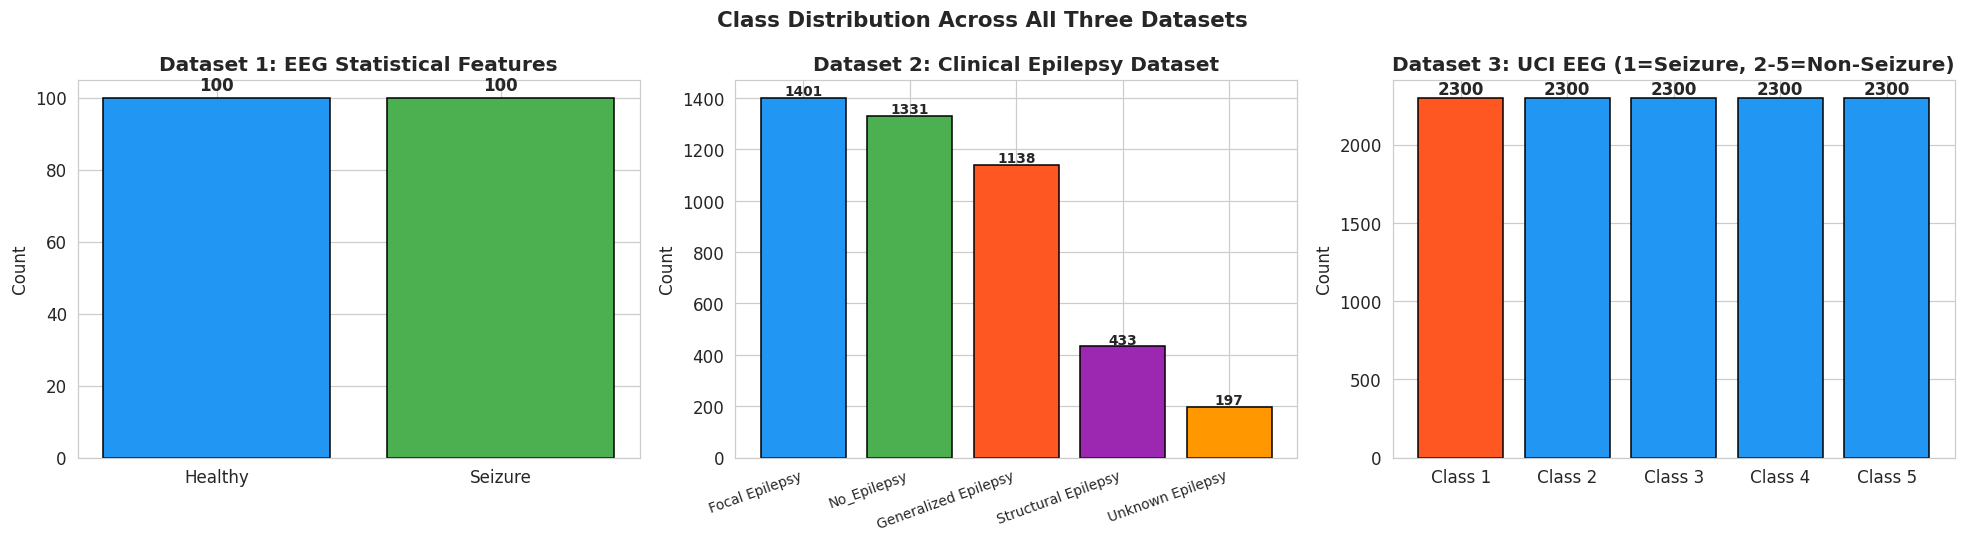

Figure saved as class_distributions.png


In [12]:
# ============================================================
# Visualize Class Distributions for all 3 Datasets
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Class Distribution Across All Three Datasets', fontsize=14, fontweight='bold')

# DS1
counts1 = df1['class'].value_counts()
axes[0].bar(counts1.index, counts1.values, color=COLORS[:2], edgecolor='black')
axes[0].set_title('Dataset 1: EEG Statistical Features', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts1.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# DS2
counts2 = df2['Target/Epilepsy Type'].value_counts()
axes[1].bar(range(len(counts2)), counts2.values, color=COLORS[:len(counts2)], edgecolor='black')
axes[1].set_title('Dataset 2: Clinical Epilepsy Dataset', fontweight='bold')
axes[1].set_xticks(range(len(counts2)))
axes[1].set_xticklabels(counts2.index, rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('Count')
for i, v in enumerate(counts2.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=9)

# DS3
counts3 = df3['y'].value_counts().sort_index()
bar_colors = ['#FF5722'] + ['#2196F3']*4
axes[2].bar([f'Class {i}' for i in counts3.index], counts3.values, color=bar_colors, edgecolor='black')
axes[2].set_title('Dataset 3: UCI EEG (1=Seizure, 2-5=Non-Seizure)', fontweight='bold')
axes[2].set_ylabel('Count')
for i, v in enumerate(counts3.values):
    axes[2].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as class_distributions.png')

## Chapter 3 — Preprocessing Pipelines

We define **two distinct preprocessing pipelines** and study how the order of operations affects model performance.

In [13]:
# ============================================================
# Prepare binary targets for all datasets
# ============================================================

# --- Dataset 1: newfeature.csv ---
X1_raw = df1.drop('class', axis=1).values.astype(float)
y1 = (df1['class'] == 'Seizure').astype(int).values
print('DS1 — Seizure ratio:', y1.mean().round(3))

# --- Dataset 2: Clinical (binary: Epilepsy vs No_Epilepsy) ---
df2_binary = df2.copy()
df2_binary['target'] = (df2['Target/Epilepsy Type'] != 'No_Epilepsy').astype(int)
# Encode all categorical columns
cat_cols = df2_binary.select_dtypes(include='object').columns.drop('Target/Epilepsy Type', errors='ignore')
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df2_binary[col] = le.fit_transform(df2_binary[col].astype(str))
    le_dict[col] = le
X2_raw = df2_binary.drop(['Target/Epilepsy Type','target'], axis=1).values.astype(float)
y2 = df2_binary['target'].values
print('DS2 — Seizure ratio:', y2.mean().round(3))

# --- Dataset 3: UCI (binary: class 1=seizure vs rest) ---
X3_raw = df3.drop(['Unnamed','y'], axis=1).values.astype(float)
y3 = (df3['y'] == 1).astype(int).values
print('DS3 — Seizure ratio:', y3.mean().round(3))

print('\nAll datasets prepared for binary classification.')

DS1 — Seizure ratio: 0.5
DS2 — Seizure ratio: 0.704
DS3 — Seizure ratio: 0.2

All datasets prepared for binary classification.


In [14]:
# ============================================================
# PIPELINE A: Clean → Normalize → Feature Selection → LR
# Purpose: Study effect of cleaning before feature reduction
# ============================================================

def pipeline_A(X, y, n_features=10, C=1.0, penalty='l2'):
    """
    Pipeline A:
    1. Missing value imputation (mean)
    2. StandardScaler normalization
    3. SelectKBest feature selection (ANOVA F-test)
    4. Logistic Regression
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    start = time.time()
    # Step 1: Impute
    imputer = SimpleImputer(strategy='mean')
    X_train = imputer.fit_transform(X_train)
    X_test  = imputer.transform(X_test)

    # Step 2: Scale
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # Step 3: Feature selection
    k = min(n_features, X_train.shape[1])
    selector = SelectKBest(f_classif, k=k)
    X_train = selector.fit_transform(X_train, y_train)
    X_test  = selector.transform(X_test)

    # Step 4: Logistic Regression
    solver = 'saga' if penalty in ['l1','elasticnet'] else 'lbfgs'
    lr_kwargs = {'C': C, 'penalty': penalty, 'solver': solver,
                 'max_iter': 1000, 'random_state': 42}
    if penalty == 'elasticnet':
        lr_kwargs['l1_ratio'] = 0.5
    model = LogisticRegression(**lr_kwargs)
    model.fit(X_train, y_train)
    elapsed = time.time() - start

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'pr_auc': average_precision_score(y_test, y_proba),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'train_time': elapsed,
        'n_features': k,
        'model': model,
        'X_test': X_test, 'y_test': y_test, 'y_pred': y_pred
    }

print('Pipeline A defined.')

Pipeline A defined.


In [15]:
# ============================================================
# PIPELINE B: Feature Extraction → Scaling → PCA → LR
# Purpose: Study effect of dimensionality reduction
# ============================================================

def pipeline_B(X, y, n_components=10, C=1.0, penalty='l2'):
    """
    Pipeline B:
    1. Missing value imputation (median)
    2. StandardScaler
    3. PCA dimensionality reduction
    4. Logistic Regression
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    start = time.time()
    # Step 1: Impute
    imputer = SimpleImputer(strategy='median')
    X_train = imputer.fit_transform(X_train)
    X_test  = imputer.transform(X_test)

    # Step 2: Scale
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # Step 3: PCA
    n_comp = min(n_components, X_train.shape[1], X_train.shape[0]-1)
    pca = PCA(n_components=n_comp, random_state=42)
    X_train = pca.fit_transform(X_train)
    X_test  = pca.transform(X_test)

    # Step 4: Logistic Regression
    solver = 'saga' if penalty in ['l1','elasticnet'] else 'lbfgs'
    lr_kwargs = {'C': C, 'penalty': penalty, 'solver': solver,
                 'max_iter': 1000, 'random_state': 42}
    if penalty == 'elasticnet':
        lr_kwargs['l1_ratio'] = 0.5
    model = LogisticRegression(**lr_kwargs)
    model.fit(X_train, y_train)
    elapsed = time.time() - start

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'pr_auc': average_precision_score(y_test, y_proba),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'train_time': elapsed,
        'n_features': n_comp,
        'model': model,
        'X_test': X_test, 'y_test': y_test, 'y_pred': y_pred
    }

print('Pipeline B defined.')

Pipeline B defined.


In [16]:
# ============================================================
# Run Pipeline A vs Pipeline B on all 3 datasets
# ============================================================
datasets = [
    ('DS1: EEG Features', X1_raw, y1, 10, 8),
    ('DS2: Clinical',     X2_raw, y2, 15, 12),
    ('DS3: UCI EEG',      X3_raw, y3, 30, 25),
]

pipeline_results = {}

print(f"{'Dataset':<22} {'Pipeline':<12} {'Accuracy':>9} {'F1':>8} {'PR-AUC':>9} {'Time(s)':>9} {'Features':>10}")
print('-' * 82)

for ds_name, X, y, k_feat, n_pca in datasets:
    rA = pipeline_A(X, y, n_features=k_feat)
    rB = pipeline_B(X, y, n_components=n_pca)
    pipeline_results[ds_name] = {'A': rA, 'B': rB}
    print(f"{ds_name:<22} {'Pipeline A':<12} {rA['accuracy']:>9.4f} {rA['f1']:>8.4f} {rA['pr_auc']:>9.4f} {rA['train_time']:>9.4f} {rA['n_features']:>10}")
    print(f"{'':22} {'Pipeline B':<12} {rB['accuracy']:>9.4f} {rB['f1']:>8.4f} {rB['pr_auc']:>9.4f} {rB['train_time']:>9.4f} {rB['n_features']:>10}")
    print('-' * 82)

Dataset                Pipeline      Accuracy       F1    PR-AUC   Time(s)   Features
----------------------------------------------------------------------------------
DS1: EEG Features      Pipeline A      1.0000   1.0000    1.0000    0.0190         10
                       Pipeline B      1.0000   1.0000    1.0000    0.0191          8
----------------------------------------------------------------------------------
DS2: Clinical          Pipeline A      1.0000   1.0000    1.0000    0.0109         15
                       Pipeline B      0.7033   0.8175    0.8254    0.0185         12
----------------------------------------------------------------------------------
DS3: UCI EEG           Pipeline A      0.8091   0.0873    0.4532    0.1299         30
                       Pipeline B      0.8048   0.0467    0.4437    0.1853         25
----------------------------------------------------------------------------------


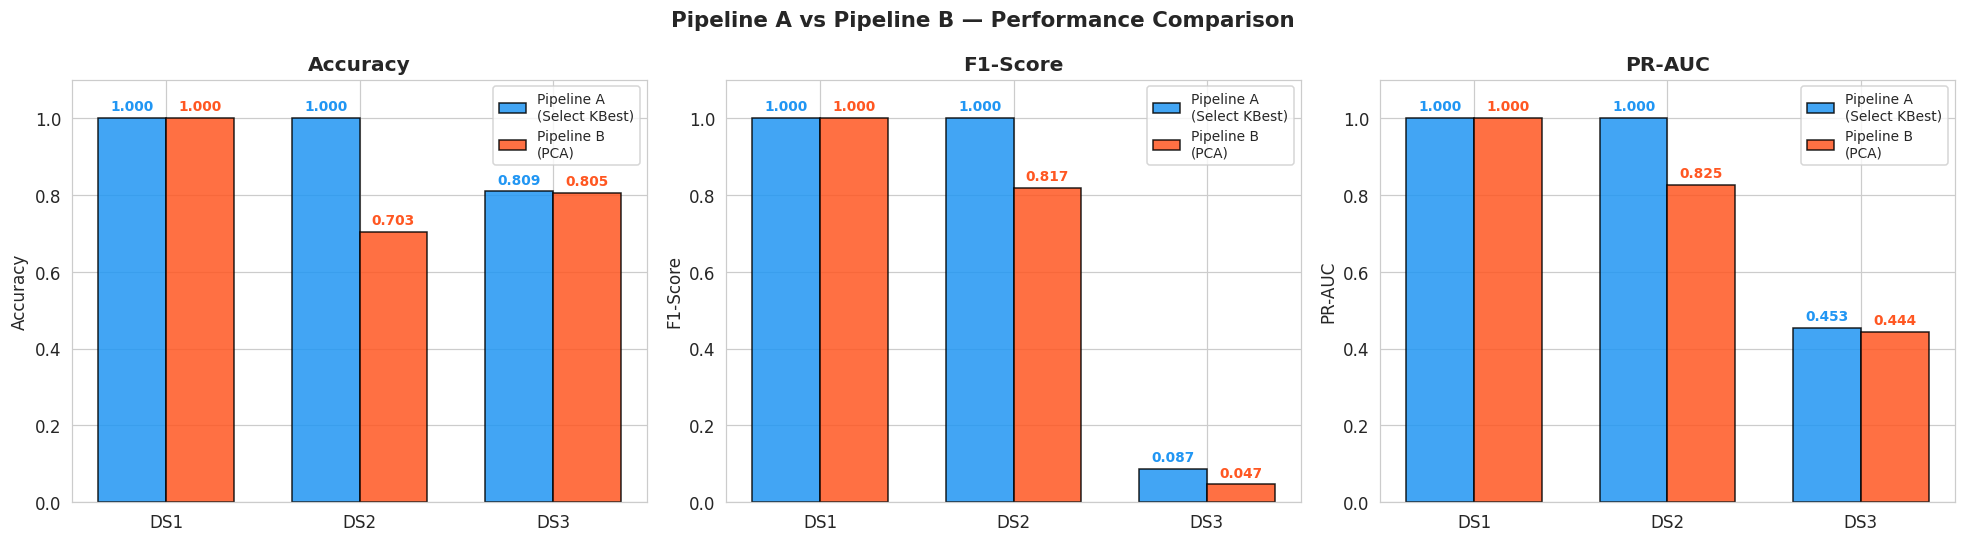

Saved: pipeline_comparison.png


In [17]:
# ============================================================
# Visualize Pipeline A vs B Comparison
# ============================================================
metrics = ['accuracy', 'f1', 'pr_auc']
metric_labels = ['Accuracy', 'F1-Score', 'PR-AUC']
ds_names = [d[0] for d in datasets]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Pipeline A vs Pipeline B — Performance Comparison', fontsize=14, fontweight='bold')

x = np.arange(len(ds_names))
width = 0.35

for ax, metric, label in zip(axes, metrics, metric_labels):
    vals_A = [pipeline_results[d]['A'][metric] for d in ds_names]
    vals_B = [pipeline_results[d]['B'][metric] for d in ds_names]
    bars1 = ax.bar(x - width/2, vals_A, width, label='Pipeline A\n(Select KBest)', color='#2196F3', alpha=0.85, edgecolor='black')
    bars2 = ax.bar(x + width/2, vals_B, width, label='Pipeline B\n(PCA)', color='#FF5722', alpha=0.85, edgecolor='black')
    ax.set_title(label, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['DS1', 'DS2', 'DS3'], fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(label)
    ax.legend(fontsize=9)
    for bar in bars1:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{bar.get_height():.3f}',
                ha='center', fontsize=9, fontweight='bold', color='#2196F3')
    for bar in bars2:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{bar.get_height():.3f}',
                ha='center', fontsize=9, fontweight='bold', color='#FF5722')

plt.tight_layout()
plt.savefig('pipeline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pipeline_comparison.png')

## Chapter 4 — Experiments & Results

### 4.1 — Overfitting and Underfitting Demonstration

We intentionally create both underfitting and overfitting scenarios by controlling regularization strength.

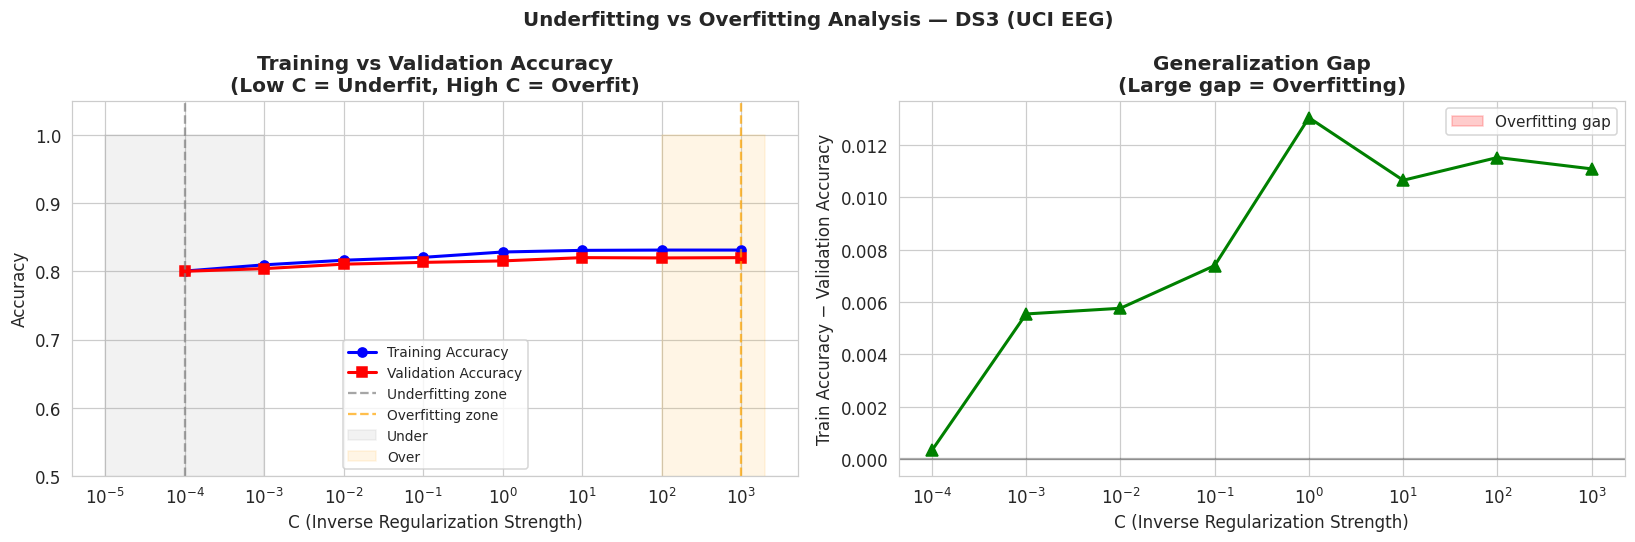


UNDERFITTING (C=0.0001): Train=0.8003, Val=0.8000
OVERFITTING  (C=1000):   Train=0.8311, Val=0.8200
GOOD FIT     (C=1):      Train=0.8283, Val=0.8152


In [18]:
# ============================================================
# Demonstrate Underfitting vs Overfitting
# Using DS3 (largest dataset) for clearer curves
# ============================================================
from sklearn.model_selection import train_test_split

# Prepare DS3 with scaling
imputer = SimpleImputer(strategy='mean')
X3_imp = imputer.fit_transform(X3_raw)
scaler  = StandardScaler()
X3_sc   = scaler.fit_transform(X3_imp)

X_tr3, X_te3, y_tr3, y_te3 = train_test_split(X3_sc, y3, test_size=0.2, random_state=42, stratify=y3)

# Regularization strength sweep
C_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_accs, test_accs = [], []

for C in C_values:
    model = LogisticRegression(C=C, solver='lbfgs', max_iter=1000, random_state=42)
    model.fit(X_tr3, y_tr3)
    train_accs.append(accuracy_score(y_tr3, model.predict(X_tr3)))
    test_accs.append(accuracy_score(y_te3, model.predict(X_te3)))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Underfitting vs Overfitting Analysis — DS3 (UCI EEG)', fontsize=13, fontweight='bold')

# Left: Accuracy vs C
ax = axes[0]
ax.semilogx(C_values, train_accs, 'b-o', label='Training Accuracy', linewidth=2)
ax.semilogx(C_values, test_accs, 'r-s', label='Validation Accuracy', linewidth=2)
ax.axvline(x=0.0001, color='gray', linestyle='--', alpha=0.7, label='Underfitting zone')
ax.axvline(x=1000,   color='orange', linestyle='--', alpha=0.7, label='Overfitting zone')
ax.fill_betweenx([0, 1], 0.00001, 0.001, alpha=0.1, color='gray', label='Under')
ax.fill_betweenx([0, 1], 100, 2000, alpha=0.1, color='orange', label='Over')
ax.set_xlabel('C (Inverse Regularization Strength)', fontsize=11)
ax.set_ylabel('Accuracy')
ax.set_title('Training vs Validation Accuracy\n(Low C = Underfit, High C = Overfit)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0.5, 1.05)

# Right: Gap between train and validation
gap = [tr - te for tr, te in zip(train_accs, test_accs)]
ax2 = axes[1]
ax2.semilogx(C_values, gap, 'g-^', linewidth=2, markersize=8)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.fill_between(C_values, gap, 0, where=[g>0.02 for g in gap], alpha=0.2, color='red', label='Overfitting gap')
ax2.set_xlabel('C (Inverse Regularization Strength)', fontsize=11)
ax2.set_ylabel('Train Accuracy − Validation Accuracy')
ax2.set_title('Generalization Gap\n(Large gap = Overfitting)', fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('overfit_underfit.png', dpi=150, bbox_inches='tight')
plt.show()

# Print extremes
print(f'\nUNDERFITTING (C=0.0001): Train={train_accs[0]:.4f}, Val={test_accs[0]:.4f}')
print(f'OVERFITTING  (C=1000):   Train={train_accs[-1]:.4f}, Val={test_accs[-1]:.4f}')
print(f'GOOD FIT     (C=1):      Train={train_accs[4]:.4f}, Val={test_accs[4]:.4f}')

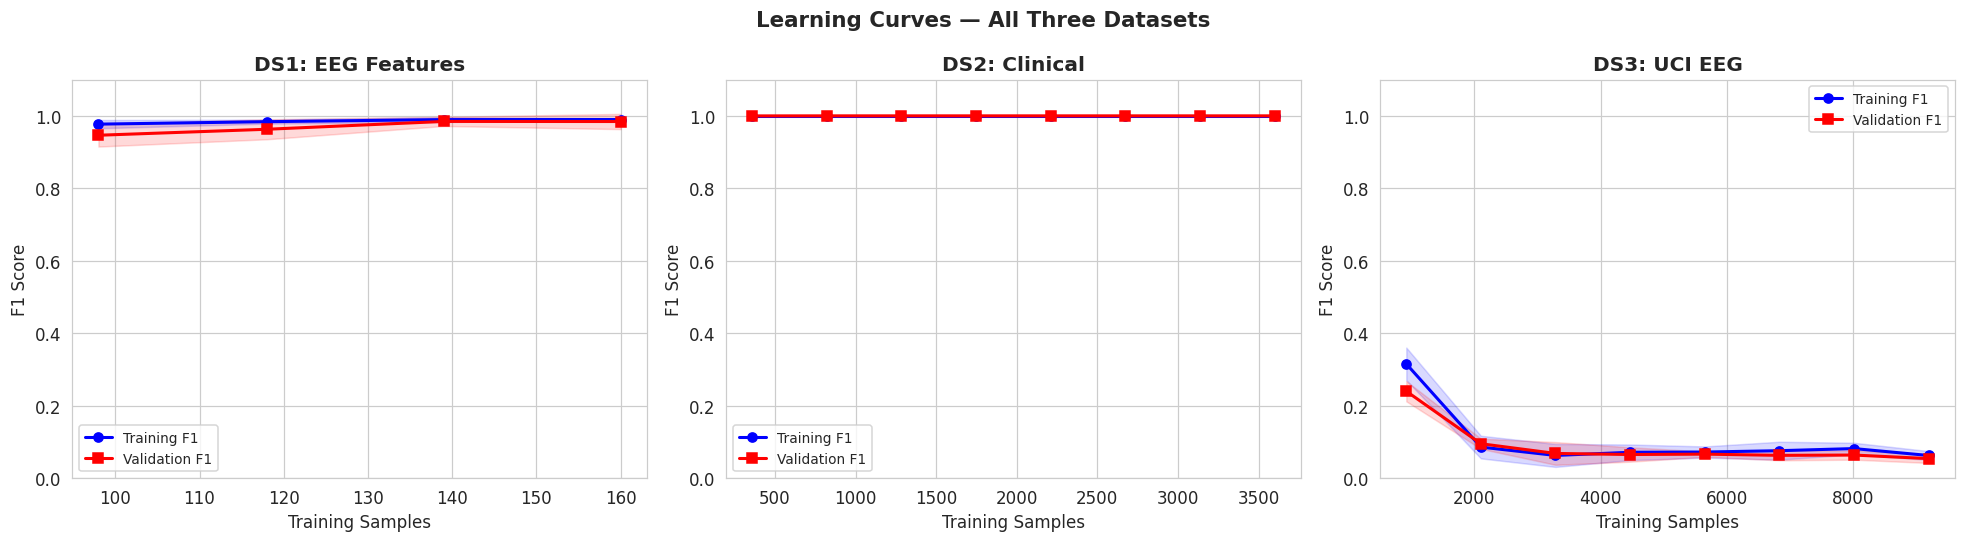

Saved: learning_curves.png


In [19]:
# ============================================================
# Learning Curves (Training size vs performance)
# ============================================================
def plot_learning_curves(X, y, title, ax, C=1.0):
    imputer = SimpleImputer(strategy='mean')
    X_imp = imputer.fit_transform(X)
    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X_imp)
    n_feat = min(20, X_sc.shape[1])
    selector = SelectKBest(f_classif, k=n_feat)
    X_sel = selector.fit_transform(X_sc, y)

    model = LogisticRegression(C=C, solver='lbfgs', max_iter=1000, random_state=42)
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_sel, y, cv=5, scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 8), random_state=42, n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'b-o', label='Training F1', linewidth=2)
    ax.plot(train_sizes, val_mean,   'r-s', label='Validation F1', linewidth=2)
    ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='blue')
    ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color='red')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Training Samples')
    ax.set_ylabel('F1 Score')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Learning Curves — All Three Datasets', fontsize=14, fontweight='bold')
plot_learning_curves(X1_raw, y1, 'DS1: EEG Features', axes[0])
plot_learning_curves(X2_raw, y2, 'DS2: Clinical', axes[1])
plot_learning_curves(X3_raw, y3, 'DS3: UCI EEG', axes[2])
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: learning_curves.png')

### 4.2 — Regularization Study (L1 vs L2 vs Elastic Net)

**L1 (Lasso):** Encourages sparsity — sets less important feature weights to exactly zero → automatic feature selection.

**L2 (Ridge):** Penalizes large weights → improves stability and reduces overfitting.

**Elastic Net:** Combination of L1 + L2 → balances sparsity and stability.

In [20]:
# ============================================================
# Regularization Comparison: L1 vs L2 vs Elastic Net
# Across all 3 datasets
# ============================================================

def evaluate_regularization(X, y, C=1.0):
    results = {}
    imputer = SimpleImputer(strategy='mean')
    X_imp = imputer.fit_transform(X)
    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X_imp)
    n_feat = min(20, X_sc.shape[1])
    selector = SelectKBest(f_classif, k=n_feat)
    X_sel = selector.fit_transform(X_sc, y)
    X_tr, X_te, y_tr, y_te = train_test_split(X_sel, y, test_size=0.2, random_state=42, stratify=y)

    regularizers = [
        ('L1 (Lasso)',    {'penalty':'l1', 'solver':'saga', 'C':C}),
        ('L2 (Ridge)',    {'penalty':'l2', 'solver':'lbfgs', 'C':C}),
        ('Elastic Net',  {'penalty':'elasticnet', 'solver':'saga', 'C':C, 'l1_ratio':0.5}),
    ]

    for name, kwargs in regularizers:
        start = time.time()
        model = LogisticRegression(max_iter=2000, random_state=42, **kwargs)
        model.fit(X_tr, y_tr)
        elapsed = time.time() - start
        y_pred  = model.predict(X_te)
        y_proba = model.predict_proba(X_te)[:, 1]
        n_zero  = np.sum(np.abs(model.coef_[0]) < 1e-6)
        results[name] = {
            'accuracy': accuracy_score(y_te, y_pred),
            'f1': f1_score(y_te, y_pred, zero_division=0),
            'pr_auc': average_precision_score(y_te, y_proba),
            'precision': precision_score(y_te, y_pred, zero_division=0),
            'recall': recall_score(y_te, y_pred, zero_division=0),
            'n_zero_weights': n_zero,
            'sparsity_pct': 100 * n_zero / X_tr.shape[1],
            'train_time': elapsed,
            'coef': model.coef_[0]
        }
    return results

# Run regularization study
reg_results = {}
print(f"{'Dataset':<22} {'Method':<15} {'Accuracy':>9} {'F1':>8} {'PR-AUC':>9} {'Sparsity%':>11}")
print('-' * 78)
for ds_name, X, y, _, _ in datasets:
    reg_results[ds_name] = evaluate_regularization(X, y)
    for method, metrics_r in reg_results[ds_name].items():
        print(f"{ds_name:<22} {method:<15} {metrics_r['accuracy']:>9.4f} {metrics_r['f1']:>8.4f} {metrics_r['pr_auc']:>9.4f} {metrics_r['sparsity_pct']:>10.1f}%")
    print('-' * 78)

Dataset                Method           Accuracy       F1    PR-AUC   Sparsity%
------------------------------------------------------------------------------
DS1: EEG Features      L1 (Lasso)         1.0000   1.0000    1.0000       63.6%
DS1: EEG Features      L2 (Ridge)         1.0000   1.0000    1.0000        0.0%
DS1: EEG Features      Elastic Net        1.0000   1.0000    1.0000       18.2%
------------------------------------------------------------------------------
DS2: Clinical          L1 (Lasso)         1.0000   1.0000    1.0000       95.0%
DS2: Clinical          L2 (Ridge)         1.0000   1.0000    1.0000        0.0%
DS2: Clinical          Elastic Net        1.0000   1.0000    1.0000       20.0%
------------------------------------------------------------------------------
DS3: UCI EEG           L1 (Lasso)         0.8065   0.0632    0.4399        5.0%
DS3: UCI EEG           L2 (Ridge)         0.8074   0.0713    0.4428        0.0%
DS3: UCI EEG           Elastic Net        0

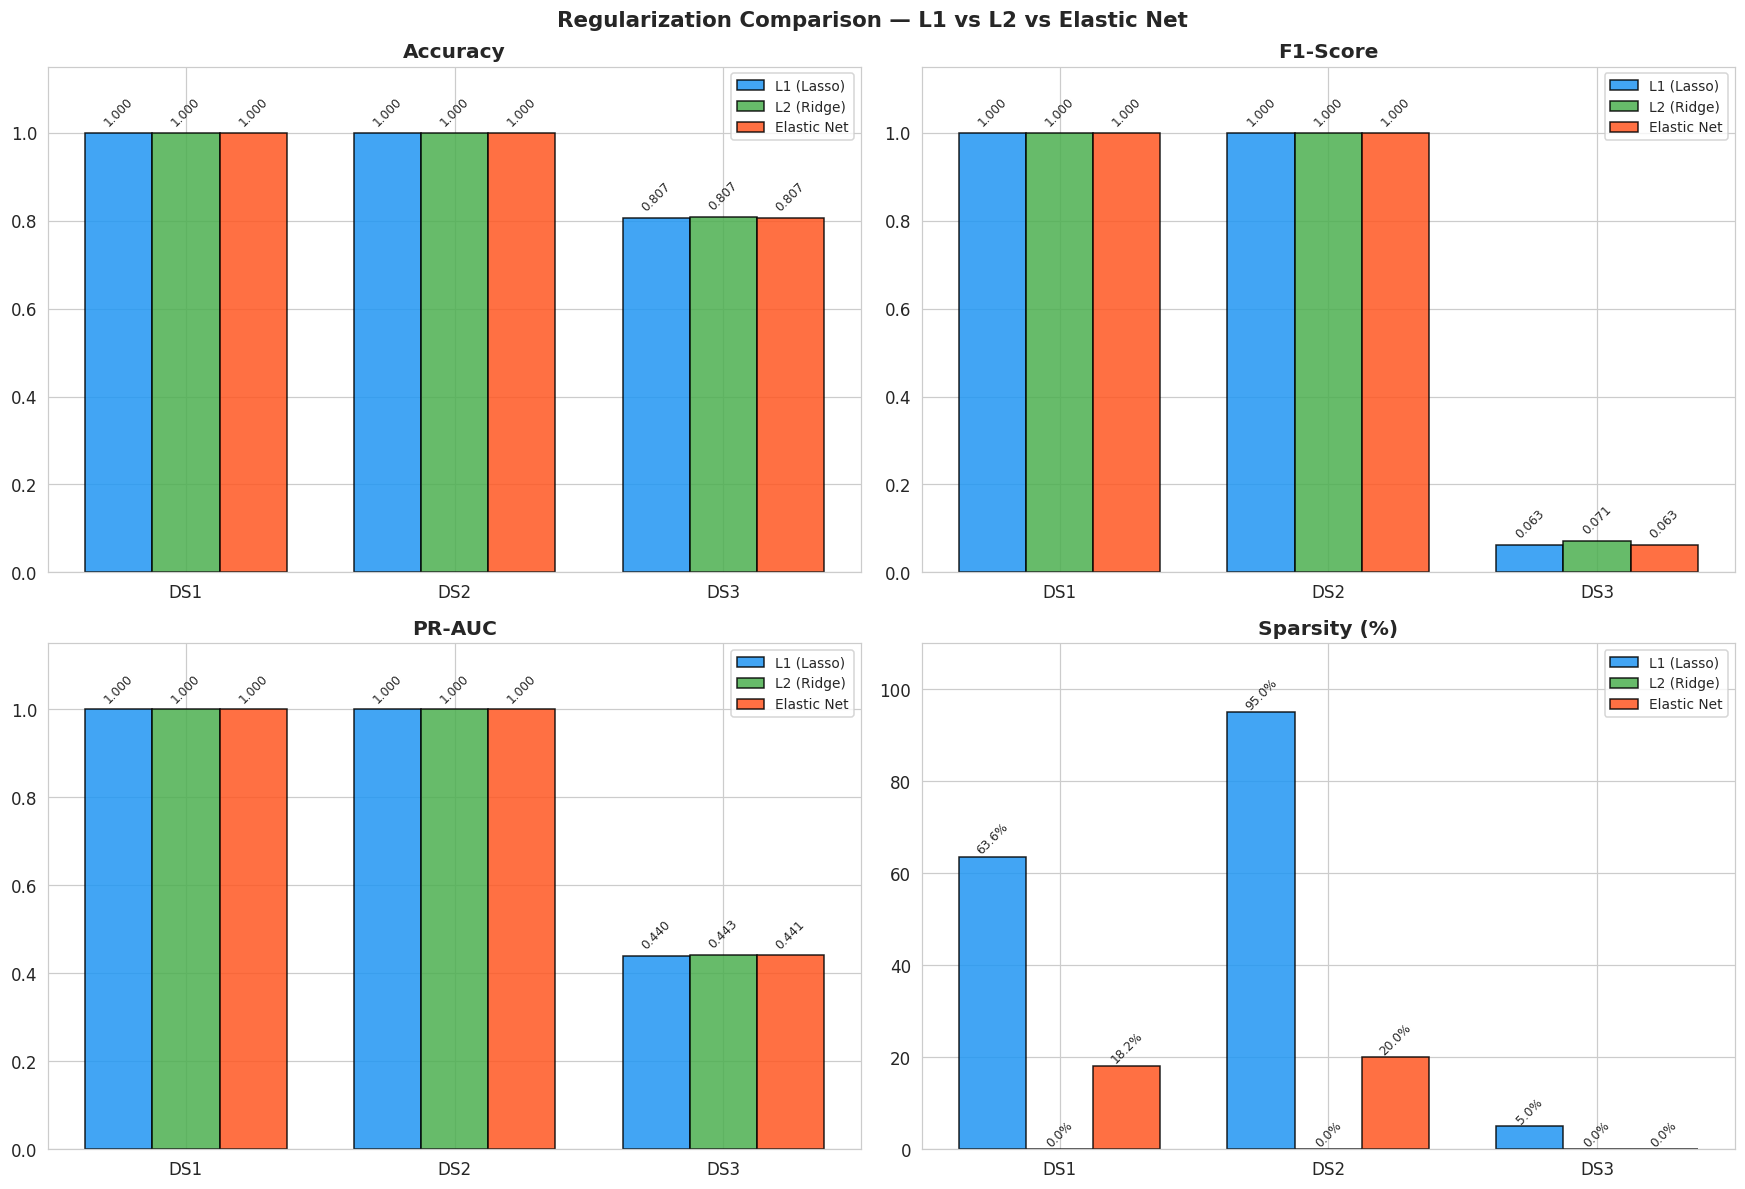

Saved: regularization_comparison.png


In [21]:
# ============================================================
# Regularization Comparison Plots
# ============================================================
reg_names = ['L1 (Lasso)', 'L2 (Ridge)', 'Elastic Net']
metrics_to_plot = ['accuracy', 'f1', 'pr_auc', 'sparsity_pct']
metric_titles  = ['Accuracy', 'F1-Score', 'PR-AUC', 'Sparsity (%)']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Regularization Comparison — L1 vs L2 vs Elastic Net', fontsize=14, fontweight='bold')
axes = axes.flatten()

for idx, (metric, title) in enumerate(zip(metrics_to_plot, metric_titles)):
    ax = axes[idx]
    x = np.arange(len(ds_names))
    width = 0.25
    for i, (reg, color) in enumerate(zip(reg_names, COLORS)):
        vals = [reg_results[d][reg][metric] for d in ds_names]
        bars = ax.bar(x + (i-1)*width, vals, width, label=reg, color=color, alpha=0.85, edgecolor='black')
        for b in bars:
            val = b.get_height()
            label_str = f'{val:.1f}%' if metric=='sparsity_pct' else f'{val:.3f}'
            ax.text(b.get_x()+b.get_width()/2, val+0.01, label_str,
                    ha='center', va='bottom', fontsize=8, rotation=45)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['DS1','DS2','DS3'])
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.15 if metric != 'sparsity_pct' else 110)

plt.tight_layout()
plt.savefig('regularization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: regularization_comparison.png')

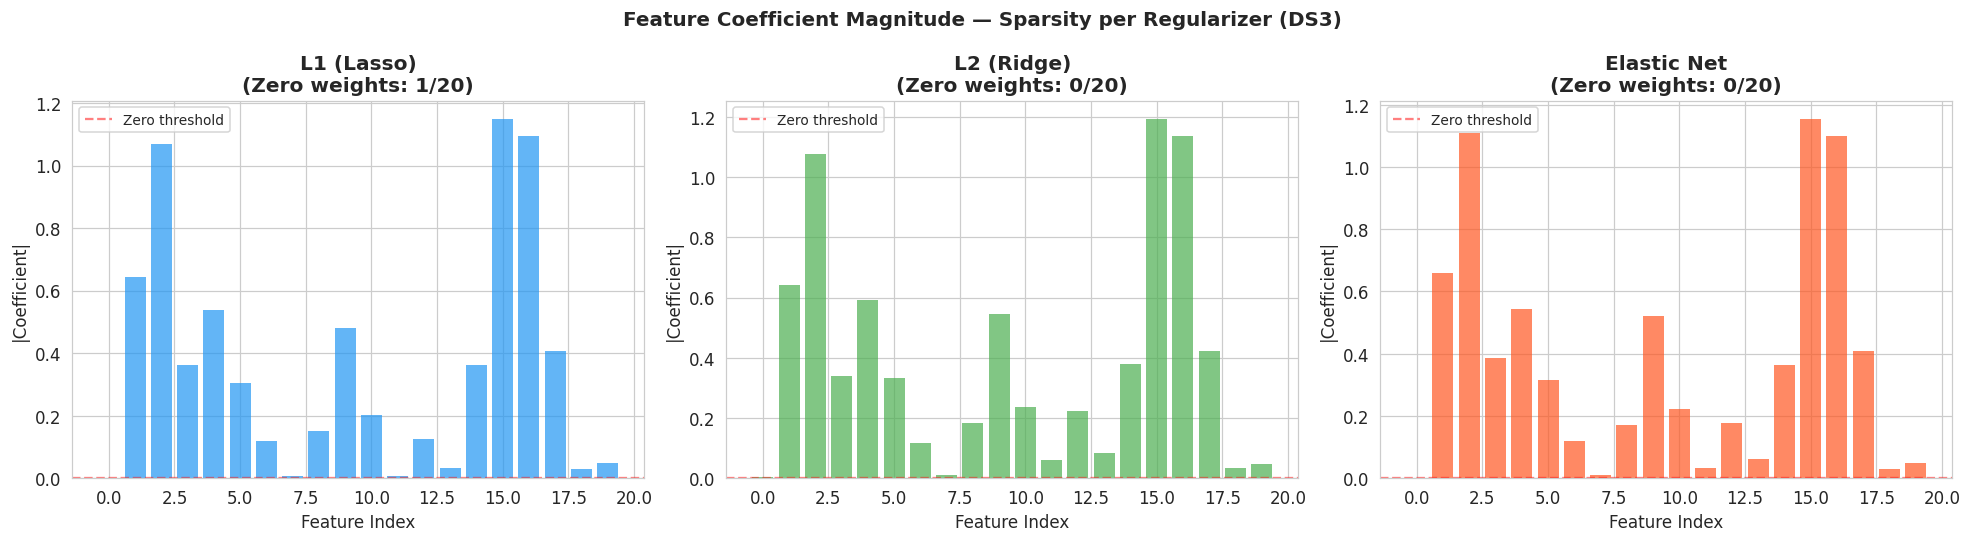

Saved: feature_sparsity.png


In [22]:
# ============================================================
# Feature Weight / Sparsity Visualization
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Feature Coefficient Magnitude — Sparsity per Regularizer (DS3)', fontsize=13, fontweight='bold')

for ax, (reg, color) in zip(axes, zip(reg_names, COLORS)):
    coef = reg_results['DS3: UCI EEG'][reg]['coef']
    feature_ids = np.arange(len(coef))
    ax.bar(feature_ids, np.abs(coef), color=color, alpha=0.7, edgecolor='none')
    ax.axhline(y=1e-6, color='red', linestyle='--', alpha=0.5, label='Zero threshold')
    n_zero = reg_results['DS3: UCI EEG'][reg]['n_zero_weights']
    ax.set_title(f'{reg}\n(Zero weights: {n_zero}/{len(coef)})', fontweight='bold')
    ax.set_xlabel('Feature Index')
    ax.set_ylabel('|Coefficient|')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('feature_sparsity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_sparsity.png')

### 4.3 — Class Imbalance Handling

EEG seizure datasets are often imbalanced (seizure events are rare). We apply three strategies:
1. **SMOTE** — Synthetic Minority Oversampling
2. **Random Undersampling** — Reduce majority class
3. **Class Weighting** — `class_weight='balanced'` in Logistic Regression

In [23]:
# ============================================================
# Create an imbalanced version of DS3 for demonstration
# (naturally DS3 is 20% seizure — more realistic)
# ============================================================
imputer_b = SimpleImputer(strategy='mean')
X3_imp_b = imputer_b.fit_transform(X3_raw)
scaler_b = StandardScaler()
X3_sc_b = scaler_b.fit_transform(X3_imp_b)
n_feat_b = min(30, X3_sc_b.shape[1])
selector_b = SelectKBest(f_classif, k=n_feat_b)
X3_sel = selector_b.fit_transform(X3_sc_b, y3)

X_tr_imb, X_te_imb, y_tr_imb, y_te_imb = train_test_split(
    X3_sel, y3, test_size=0.2, random_state=42, stratify=y3)

print(f'Training set - Seizure: {y_tr_imb.sum()}, Non-seizure: {(y_tr_imb==0).sum()}')
print(f'Seizure ratio in training: {y_tr_imb.mean():.2%}')

def eval_model(X_tr, y_tr, X_te, y_te, method_name, class_weight=None):
    model = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42,
                                class_weight=class_weight)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    return {
        'method': method_name,
        'accuracy': accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred, zero_division=0),
        'recall': recall_score(y_te, y_pred, zero_division=0),
        'f1': f1_score(y_te, y_pred, zero_division=0),
        'pr_auc': average_precision_score(y_te, y_proba),
        'y_pred': y_pred, 'y_proba': y_proba
    }

imbalance_results = []

# 1. No balancing (baseline)
r = eval_model(X_tr_imb, y_tr_imb, X_te_imb, y_te_imb, 'No Balancing')
imbalance_results.append(r)

# 2. SMOTE
sm = SMOTE(random_state=42)
X_sm, y_sm = sm.fit_resample(X_tr_imb, y_tr_imb)
print(f'After SMOTE — Seizure: {y_sm.sum()}, Non-seizure: {(y_sm==0).sum()}')
r = eval_model(X_sm, y_sm, X_te_imb, y_te_imb, 'SMOTE')
imbalance_results.append(r)

# 3. Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_tr_imb, y_tr_imb)
print(f'After Undersampling — Seizure: {y_rus.sum()}, Non-seizure: {(y_rus==0).sum()}')
r = eval_model(X_rus, y_rus, X_te_imb, y_te_imb, 'Undersampling')
imbalance_results.append(r)

# 4. Class weighting
r = eval_model(X_tr_imb, y_tr_imb, X_te_imb, y_te_imb, 'Class Weighting', class_weight='balanced')
imbalance_results.append(r)

# Print results
print(f"\n{'Method':<18} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'PR-AUC':>9}")
print('-' * 68)
for r in imbalance_results:
    print(f"{r['method']:<18} {r['accuracy']:>9.4f} {r['precision']:>10.4f} {r['recall']:>8.4f} {r['f1']:>8.4f} {r['pr_auc']:>9.4f}")

Training set - Seizure: 1840, Non-seizure: 7360
Seizure ratio in training: 20.00%
After SMOTE — Seizure: 7360, Non-seizure: 7360
After Undersampling — Seizure: 1840, Non-seizure: 1840

Method              Accuracy  Precision   Recall       F1    PR-AUC
--------------------------------------------------------------------
No Balancing          0.8074     1.0000   0.0370   0.0713    0.4542
SMOTE                 0.6387     0.2667   0.4609   0.3378    0.4430
Undersampling         0.6274     0.2623   0.4761   0.3382    0.4472
Class Weighting       0.6326     0.2638   0.4674   0.3373    0.4434


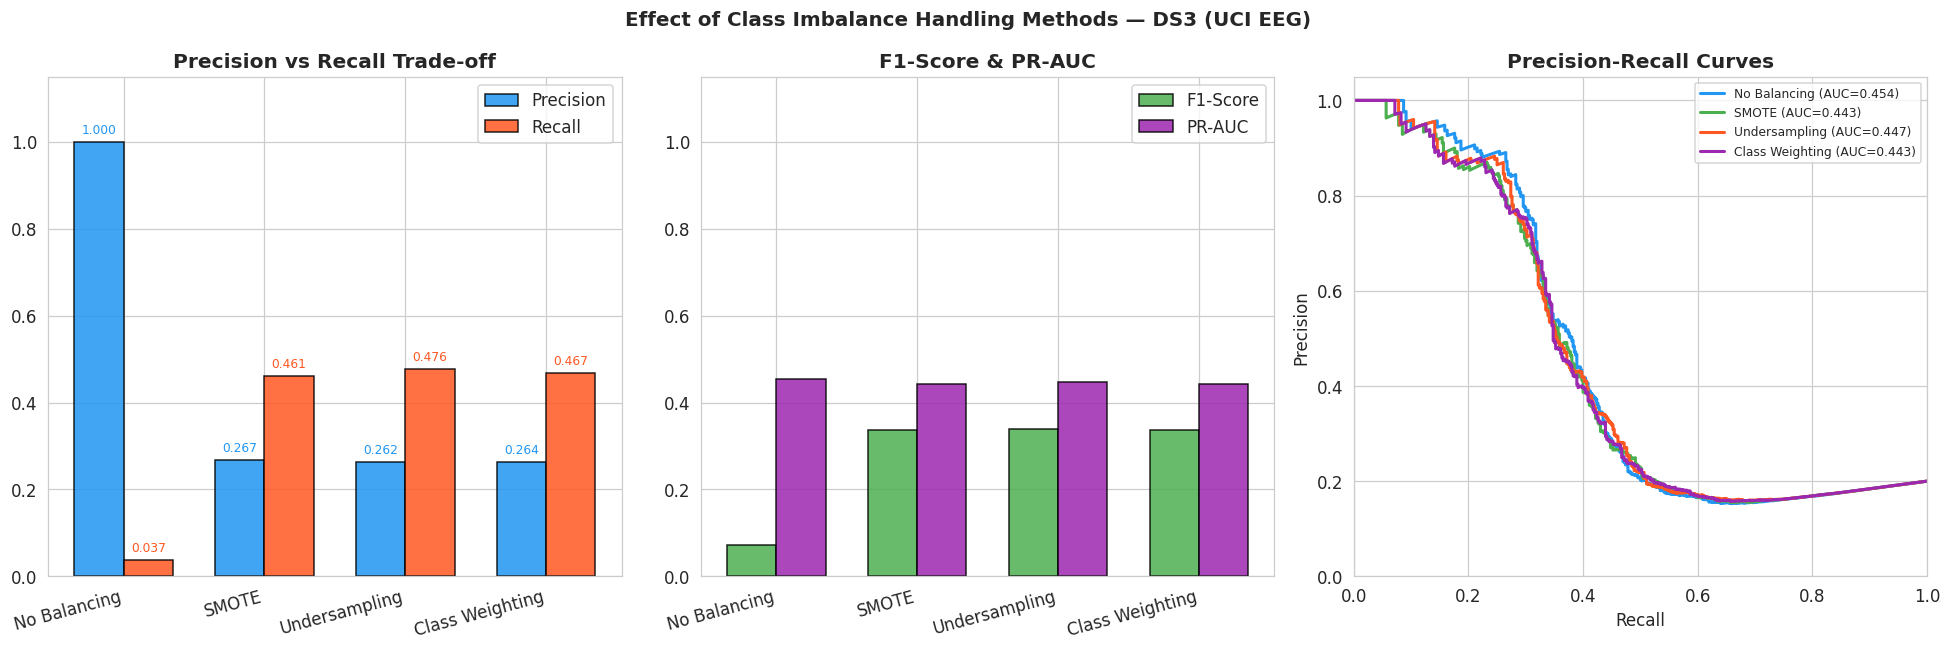

Saved: imbalance_handling.png


In [24]:
# ============================================================
# Visualize Imbalance Handling Results
# ============================================================
method_names = [r['method'] for r in imbalance_results]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Effect of Class Imbalance Handling Methods — DS3 (UCI EEG)', fontsize=13, fontweight='bold')

# Precision-Recall bar chart
prec_vals = [r['precision'] for r in imbalance_results]
rec_vals  = [r['recall'] for r in imbalance_results]
x = np.arange(len(method_names))
w = 0.35
axes[0].bar(x-w/2, prec_vals, w, label='Precision', color='#2196F3', alpha=0.85, edgecolor='black')
axes[0].bar(x+w/2, rec_vals,  w, label='Recall',    color='#FF5722', alpha=0.85, edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(method_names, rotation=15, ha='right')
axes[0].set_title('Precision vs Recall Trade-off', fontweight='bold')
axes[0].set_ylim(0, 1.15)
axes[0].legend()
for i, (p, r2) in enumerate(zip(prec_vals, rec_vals)):
    axes[0].text(i-w/2, p+0.02, f'{p:.3f}', ha='center', fontsize=8, color='#2196F3')
    axes[0].text(i+w/2, r2+0.02, f'{r2:.3f}', ha='center', fontsize=8, color='#FF5722')

# F1 and PR-AUC
f1_vals    = [r['f1'] for r in imbalance_results]
prauc_vals = [r['pr_auc'] for r in imbalance_results]
axes[1].bar(x-w/2, f1_vals,    w, label='F1-Score', color='#4CAF50', alpha=0.85, edgecolor='black')
axes[1].bar(x+w/2, prauc_vals, w, label='PR-AUC',   color='#9C27B0', alpha=0.85, edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(method_names, rotation=15, ha='right')
axes[1].set_title('F1-Score & PR-AUC', fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].legend()

# PR Curves
ax3 = axes[2]
for r, color in zip(imbalance_results, COLORS):
    prec_c, rec_c, _ = precision_recall_curve(y_te_imb, r['y_proba'])
    ax3.plot(rec_c, prec_c, label=f"{r['method']} (AUC={r['pr_auc']:.3f})", color=color, linewidth=2)
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curves', fontweight='bold')
ax3.legend(fontsize=8)
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('imbalance_handling.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: imbalance_handling.png')

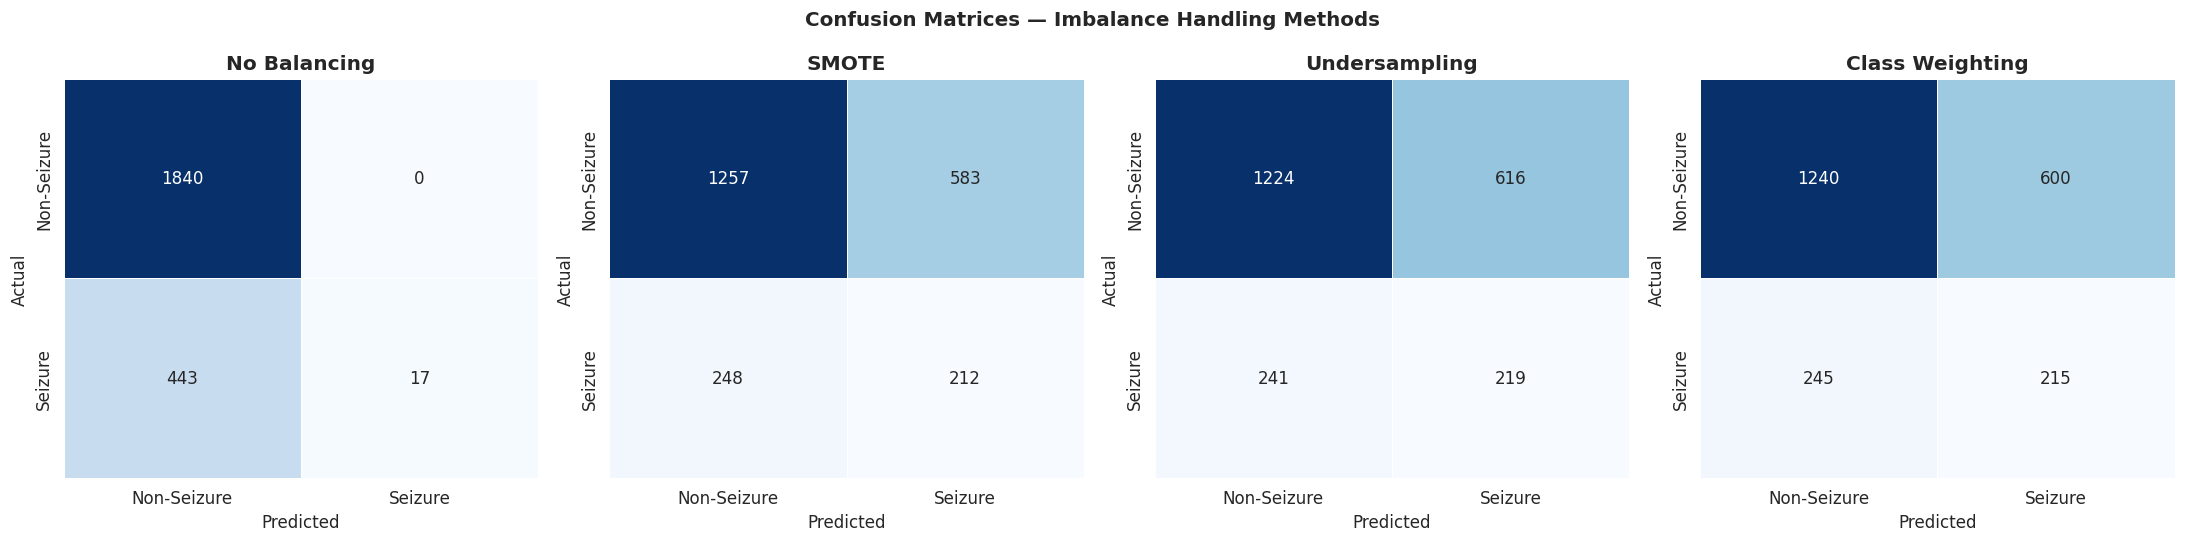

Saved: confusion_matrices.png


In [25]:
# ============================================================
# Confusion Matrices — All Methods
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Confusion Matrices — Imbalance Handling Methods', fontsize=13, fontweight='bold')

for ax, r, color in zip(axes, imbalance_results, COLORS):
    cm = confusion_matrix(y_te_imb, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Non-Seizure','Seizure'],
                yticklabels=['Non-Seizure','Seizure'],
                cbar=False, linewidths=0.5)
    ax.set_title(r['method'], fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

### 4.4 — Combined: SMOTE + Regularization Study

Investigating how imbalance handling interacts with regularization.

In [26]:
# ============================================================
# SMOTE + L1 / L2 / Elastic Net — Interaction Study
# ============================================================
combined_results = []

regularizers_cfg = [
    ('L1', {'penalty':'l1', 'solver':'saga', 'C':1.0}),
    ('L2', {'penalty':'l2', 'solver':'lbfgs', 'C':1.0}),
    ('Elastic Net', {'penalty':'elasticnet', 'solver':'saga', 'C':1.0, 'l1_ratio':0.5}),
]

sampling_methods = [
    ('No Balancing', None, None),
    ('SMOTE',        'smote', None),
    ('Class Weight', None, 'balanced'),
]

print(f"{'Sampling':<15} {'Regularizer':<14} {'Accuracy':>9} {'F1':>8} {'PR-AUC':>9} {'Recall':>8}")
print('-' * 70)

for samp_name, samp_type, cw in sampling_methods:
    if samp_type == 'smote':
        sm = SMOTE(random_state=42)
        X_tr_s, y_tr_s = sm.fit_resample(X_tr_imb, y_tr_imb)
    else:
        X_tr_s, y_tr_s = X_tr_imb, y_tr_imb

    for reg_name, kwargs in regularizers_cfg:
        model = LogisticRegression(max_iter=2000, random_state=42, class_weight=cw, **kwargs)
        model.fit(X_tr_s, y_tr_s)
        y_pred = model.predict(X_te_imb)
        y_proba = model.predict_proba(X_te_imb)[:, 1]
        row = {
            'sampling': samp_name, 'regularizer': reg_name,
            'accuracy': accuracy_score(y_te_imb, y_pred),
            'f1': f1_score(y_te_imb, y_pred, zero_division=0),
            'pr_auc': average_precision_score(y_te_imb, y_proba),
            'recall': recall_score(y_te_imb, y_pred, zero_division=0)
        }
        combined_results.append(row)
        print(f"{samp_name:<15} {reg_name:<14} {row['accuracy']:>9.4f} {row['f1']:>8.4f} {row['pr_auc']:>9.4f} {row['recall']:>8.4f}")
    print()

combined_df = pd.DataFrame(combined_results)
print('\nBest configuration by F1-Score:')
print(combined_df.loc[combined_df['f1'].idxmax()])

Sampling        Regularizer     Accuracy       F1    PR-AUC   Recall
----------------------------------------------------------------------
No Balancing    L1                0.8078   0.0753    0.4568   0.0391
No Balancing    L2                0.8074   0.0713    0.4542   0.0370
No Balancing    Elastic Net       0.8078   0.0753    0.4566   0.0391

SMOTE           L1                0.6417   0.3419    0.4442   0.4652
SMOTE           L2                0.6387   0.3378    0.4430   0.4609
SMOTE           Elastic Net       0.6400   0.3408    0.4444   0.4652

Class Weight    L1                0.6348   0.3386    0.4453   0.4674
Class Weight    L2                0.6326   0.3373    0.4434   0.4674
Class Weight    Elastic Net       0.6374   0.3402    0.4446   0.4674


Best configuration by F1-Score:
sampling          SMOTE
regularizer          L1
accuracy       0.641739
f1             0.341853
pr_auc         0.444208
recall         0.465217
Name: 3, dtype: object


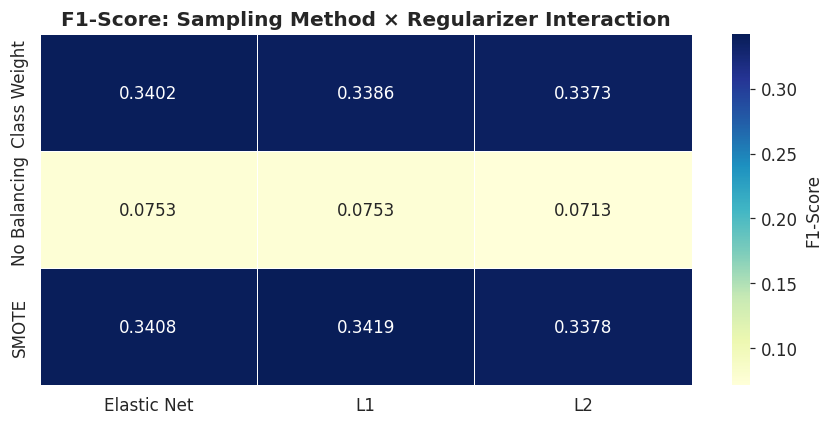

Saved: heatmap_f1.png


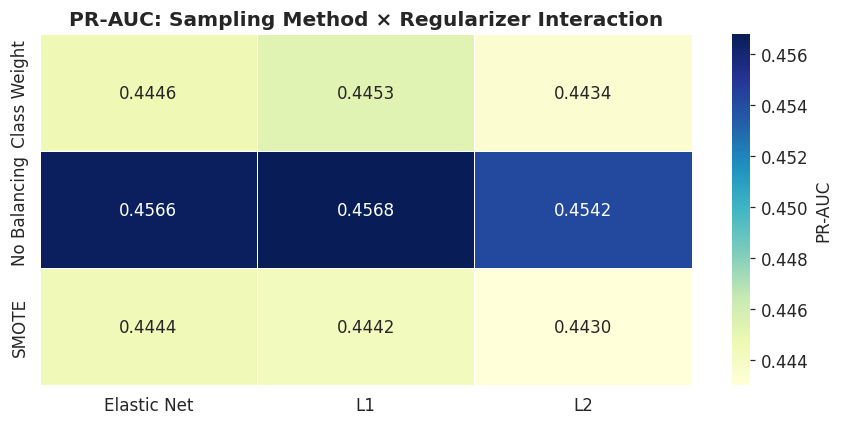

Saved: heatmap_pr_auc.png


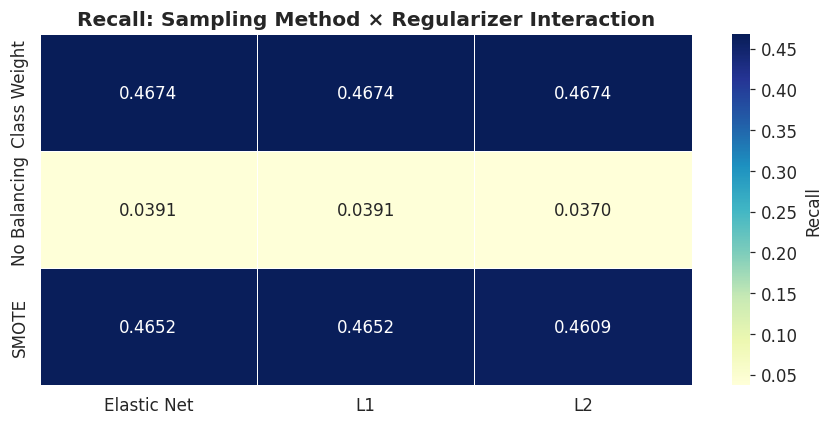

Saved: heatmap_recall.png


In [27]:
# ============================================================
# Heatmap: SMOTE x Regularizer interactions
# ============================================================
for metric, title in [('f1', 'F1-Score'), ('pr_auc', 'PR-AUC'), ('recall', 'Recall')]:
    pivot = combined_df.pivot(index='sampling', columns='regularizer', values=metric)
    pivot.columns.name = None
    pivot.index.name = None
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax,
                linewidths=0.5, cbar_kws={'label': title})
    ax.set_title(f'{title}: Sampling Method × Regularizer Interaction', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'heatmap_{metric}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: heatmap_{metric}.png')

### 4.5 — Comprehensive Final Comparison Table

In [28]:
# ============================================================
# Master Comparison: All Methods on All Datasets
# ============================================================
master_rows = []

for ds_name, X, y, k_feat, n_pca in datasets:
    imputer_m = SimpleImputer(strategy='mean')
    X_imp_m = imputer_m.fit_transform(X)
    scaler_m = StandardScaler()
    X_sc_m = scaler_m.fit_transform(X_imp_m)
    n_feat_m = min(20, X_sc_m.shape[1])
    selector_m = SelectKBest(f_classif, k=n_feat_m)
    X_sel_m = selector_m.fit_transform(X_sc_m, y)
    X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
        X_sel_m, y, test_size=0.2, random_state=42, stratify=y)

    for pen, solver, extra, tag in [
        ('l2', 'lbfgs', {},       'No Balancing + L2'),
        ('l1', 'saga',  {},       'No Balancing + L1'),
        ('elasticnet','saga',{'l1_ratio':0.5}, 'No Balancing + ElasticNet'),
    ]:
        model = LogisticRegression(penalty=pen, C=1.0, solver=solver, max_iter=2000,
                                    random_state=42, **extra)
        model.fit(X_tr_m, y_tr_m)
        y_pred = model.predict(X_te_m)
        y_proba = model.predict_proba(X_te_m)[:, 1]
        master_rows.append({
            'Dataset': ds_name, 'Method': tag,
            'Accuracy': round(accuracy_score(y_te_m, y_pred), 4),
            'Precision': round(precision_score(y_te_m, y_pred, zero_division=0), 4),
            'Recall': round(recall_score(y_te_m, y_pred, zero_division=0), 4),
            'F1-Score': round(f1_score(y_te_m, y_pred, zero_division=0), 4),
            'PR-AUC': round(average_precision_score(y_te_m, y_proba), 4),
        })

    # Also add SMOTE + Elastic Net
    if y_tr_m.sum() > 1 and (y_tr_m == 0).sum() > 1:
        try:
            sm2 = SMOTE(random_state=42)
            X_sm2, y_sm2 = sm2.fit_resample(X_tr_m, y_tr_m)
            model = LogisticRegression(penalty='elasticnet', C=1.0, solver='saga',
                                        l1_ratio=0.5, max_iter=2000, random_state=42)
            model.fit(X_sm2, y_sm2)
            y_pred = model.predict(X_te_m)
            y_proba = model.predict_proba(X_te_m)[:, 1]
            master_rows.append({
                'Dataset': ds_name, 'Method': 'SMOTE + ElasticNet',
                'Accuracy': round(accuracy_score(y_te_m, y_pred), 4),
                'Precision': round(precision_score(y_te_m, y_pred, zero_division=0), 4),
                'Recall': round(recall_score(y_te_m, y_pred, zero_division=0), 4),
                'F1-Score': round(f1_score(y_te_m, y_pred, zero_division=0), 4),
                'PR-AUC': round(average_precision_score(y_te_m, y_proba), 4),
            })
        except Exception:
            pass

master_df = pd.DataFrame(master_rows)
print('MASTER COMPARISON TABLE:')
display(master_df.sort_values(['Dataset','F1-Score'], ascending=[True, False]))

MASTER COMPARISON TABLE:


,Dataset,Method,Accuracy,Precision,Recall,F1-Score,PR-AUC
0,DS1: EEG Features,No Balancing + L2,1.0000,1.0000,1.0000,1.0000,1.0000
1,DS1: EEG Features,No Balancing + L1,1.0000,1.0000,1.0000,1.0000,1.0000
2,DS1: EEG Features,No Balancing + ElasticNet,1.0000,1.0000,1.0000,1.0000,1.0000
3,DS1: EEG Features,SMOTE + ElasticNet,1.0000,1.0000,1.0000,1.0000,1.0000
4,DS2: Clinical,No Balancing + L2,1.0000,1.0000,1.0000,1.0000,1.0000
5,DS2: Clinical,No Balancing + L1,1.0000,1.0000,1.0000,1.0000,1.0000
6,DS2: Clinical,No Balancing + ElasticNet,1.0000,1.0000,1.0000,1.0000,1.0000
7,DS2: Clinical,SMOTE + ElasticNet,1.0000,1.0000,1.0000,1.0000,1.0000
11,DS3: UCI EEG,SMOTE + ElasticNet,0.6130,0.2494,0.4652,0.3247,0.4230
8,DS3: UCI EEG,No Balancing + L2,0.8074,1.0000,0.0370,0.0713,0.4428


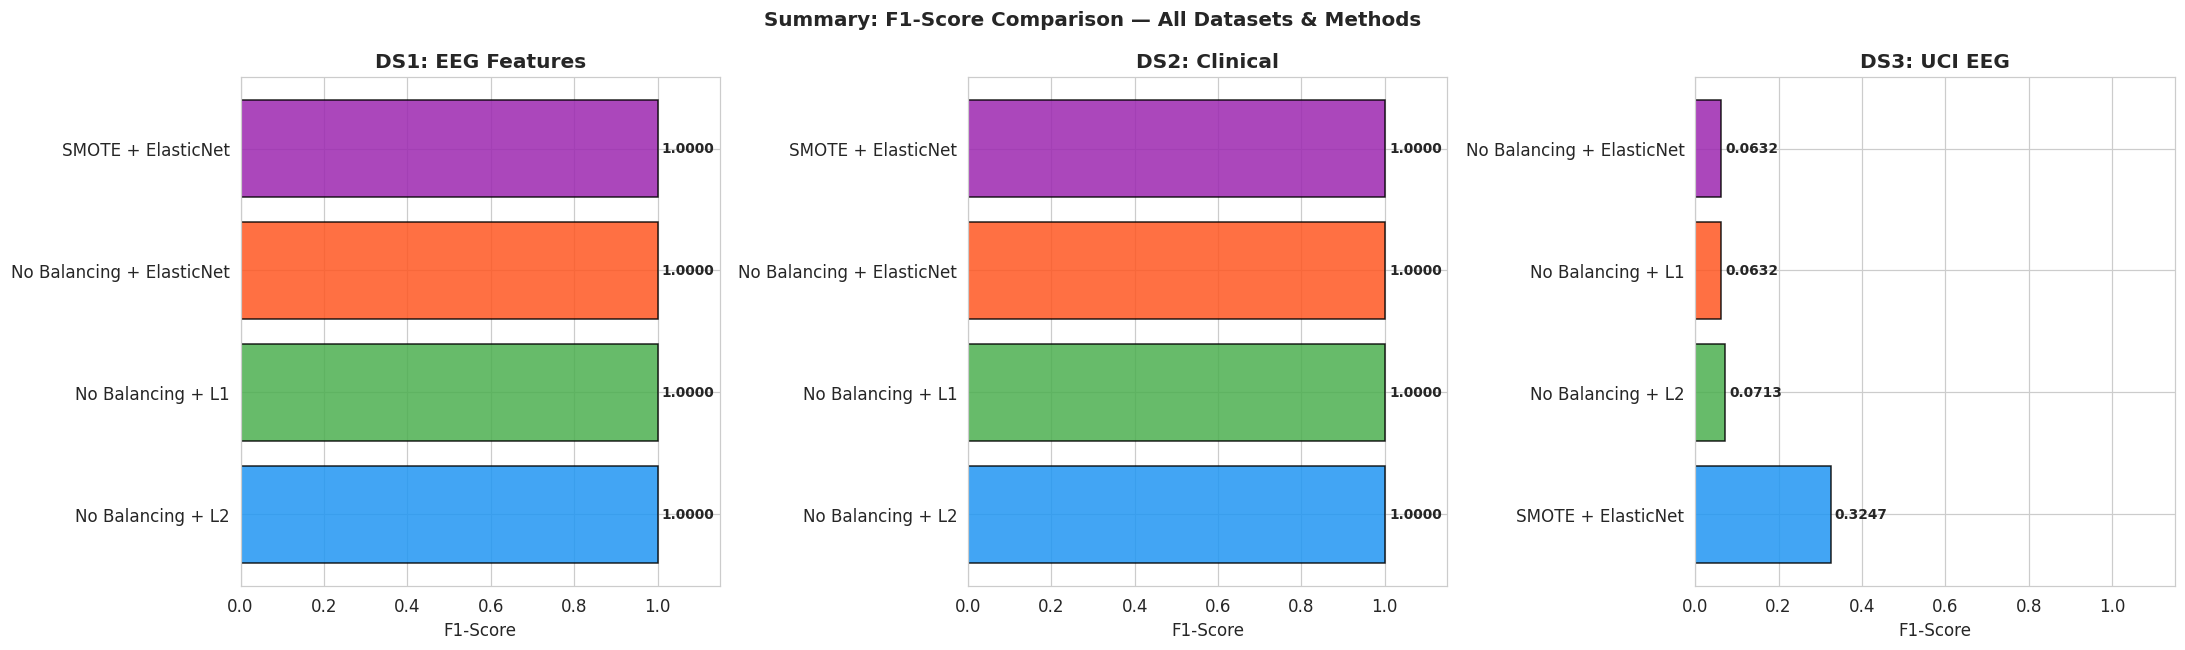

Saved: summary_f1.png


In [29]:
# ============================================================
# Final Summary Bar Charts
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Summary: F1-Score Comparison — All Datasets & Methods', fontsize=13, fontweight='bold')

for ax, (ds_name, _, _, _, _) in zip(axes, datasets):
    subset = master_df[master_df['Dataset'] == ds_name].sort_values('F1-Score', ascending=False)
    bar_colors = [COLORS[i % len(COLORS)] for i in range(len(subset))]
    bars = ax.barh(subset['Method'], subset['F1-Score'], color=bar_colors, alpha=0.85, edgecolor='black')
    ax.set_xlim(0, 1.15)
    ax.set_title(ds_name, fontweight='bold')
    ax.set_xlabel('F1-Score')
    for bar, val in zip(bars, subset['F1-Score']):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('summary_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: summary_f1.png')

## Chapter 5 — Comparative Analysis

### Research Question 1: Does preprocessing order affect results?

Run the cell below to generate a written analysis based on your results.

In [30]:
# ============================================================
# Auto-generate Analysis Summary from Results
# ============================================================

print('='*70)
print('CHAPTER 5 — COMPARATIVE ANALYSIS')
print('='*70)

# Q1: Preprocessing order
print('\n--- Q1: Does preprocessing order affect results? ---')
for ds_name, _, _, _, _ in datasets:
    rA = pipeline_results[ds_name]['A']
    rB = pipeline_results[ds_name]['B']
    diff_f1 = rA['f1'] - rB['f1']
    winner = 'Pipeline A (SelectKBest)' if diff_f1 > 0 else 'Pipeline B (PCA)'
    print(f'  {ds_name}: {winner} wins by F1 delta={abs(diff_f1):.4f}')
    print(f'    Pipeline A => Acc={rA["accuracy"]:.4f}, F1={rA["f1"]:.4f}, PR-AUC={rA["pr_auc"]:.4f}')
    print(f'    Pipeline B => Acc={rB["accuracy"]:.4f}, F1={rB["f1"]:.4f}, PR-AUC={rB["pr_auc"]:.4f}')

# Q2: Which regularization generalizes best?
print('\n--- Q2: Which regularization generalizes best across datasets? ---')
for reg in ['L1 (Lasso)', 'L2 (Ridge)', 'Elastic Net']:
    avg_f1 = np.mean([reg_results[d][reg]['f1'] for d, _, _, _, _ in datasets])
    avg_prauc = np.mean([reg_results[d][reg]['pr_auc'] for d, _, _, _, _ in datasets])
    print(f'  {reg:<15} => Avg F1={avg_f1:.4f}, Avg PR-AUC={avg_prauc:.4f}')

# Q3: Does Elastic Net consistently outperform?
print('\n--- Q3: Does Elastic Net consistently outperform L1/L2? ---')
for d, _, _, _, _ in datasets:
    l1_f1 = reg_results[d]['L1 (Lasso)']['f1']
    l2_f1 = reg_results[d]['L2 (Ridge)']['f1']
    en_f1 = reg_results[d]['Elastic Net']['f1']
    best = max([('L1',l1_f1),('L2',l2_f1),('EN',en_f1)], key=lambda x: x[1])
    print(f'  {d}: Best={best[0]} (F1={best[1]:.4f}) | L1={l1_f1:.4f} L2={l2_f1:.4f} EN={en_f1:.4f}')

# Q4: Imbalance + Regularization
print('\n--- Q4: How does imbalance handling interact with regularization? ---')
best_combo = combined_df.loc[combined_df['f1'].idxmax()]
print(f'  Best combination: {best_combo["sampling"]} + {best_combo["regularizer"]}')
print(f'  F1={best_combo["f1"]:.4f}, PR-AUC={best_combo["pr_auc"]:.4f}, Recall={best_combo["recall"]:.4f}')
print(f'  SMOTE improves recall by generating synthetic minority samples.')
print(f'  Class weighting directly penalizes misclassification of minority class.')
print(f'  L1 may hurt imbalanced datasets by zeroing minority-sensitive features.')

print('\n' + '='*70)

CHAPTER 5 — COMPARATIVE ANALYSIS

--- Q1: Does preprocessing order affect results? ---
  DS1: EEG Features: Pipeline B (PCA) wins by F1 delta=0.0000
    Pipeline A => Acc=1.0000, F1=1.0000, PR-AUC=1.0000
    Pipeline B => Acc=1.0000, F1=1.0000, PR-AUC=1.0000
  DS2: Clinical: Pipeline A (SelectKBest) wins by F1 delta=0.1825
    Pipeline A => Acc=1.0000, F1=1.0000, PR-AUC=1.0000
    Pipeline B => Acc=0.7033, F1=0.8175, PR-AUC=0.8254
  DS3: UCI EEG: Pipeline A (SelectKBest) wins by F1 delta=0.0406
    Pipeline A => Acc=0.8091, F1=0.0873, PR-AUC=0.4532
    Pipeline B => Acc=0.8048, F1=0.0467, PR-AUC=0.4437

--- Q2: Which regularization generalizes best across datasets? ---
  L1 (Lasso)      => Avg F1=0.6877, Avg PR-AUC=0.8133
  L2 (Ridge)      => Avg F1=0.6904, Avg PR-AUC=0.8143
  Elastic Net     => Avg F1=0.6877, Avg PR-AUC=0.8136

--- Q3: Does Elastic Net consistently outperform L1/L2? ---
  DS1: EEG Features: Best=L1 (F1=1.0000) | L1=1.0000 L2=1.0000 EN=1.0000
  DS2: Clinical: Best=L1 (

## Chapter 6 — Conclusion

In [31]:
# ============================================================
# Print Classification Reports for best configurations
# ============================================================
print('='*70)
print('DETAILED CLASSIFICATION REPORTS — Best Configurations')
print('='*70)

for ds_name, X, y, k_feat, _ in datasets:
    print(f'\n--- {ds_name} — Pipeline A + L2 ---')
    r = pipeline_A(X, y, n_features=k_feat, penalty='l2')
    print(classification_report(r['y_test'], r['y_pred'], target_names=['Non-Seizure','Seizure']))

DETAILED CLASSIFICATION REPORTS — Best Configurations

--- DS1: EEG Features — Pipeline A + L2 ---
              precision    recall  f1-score   support

 Non-Seizure       1.00      1.00      1.00        20
     Seizure       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40


--- DS2: Clinical — Pipeline A + L2 ---
              precision    recall  f1-score   support

 Non-Seizure       1.00      1.00      1.00       266
     Seizure       1.00      1.00      1.00       634

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900


--- DS3: UCI EEG — Pipeline A + L2 ---
              precision    recall  f1-score   support

 Non-Seizure       0.81      1.00      0.89      1840
     Seizure       1.00      0.05      0.09       460

  

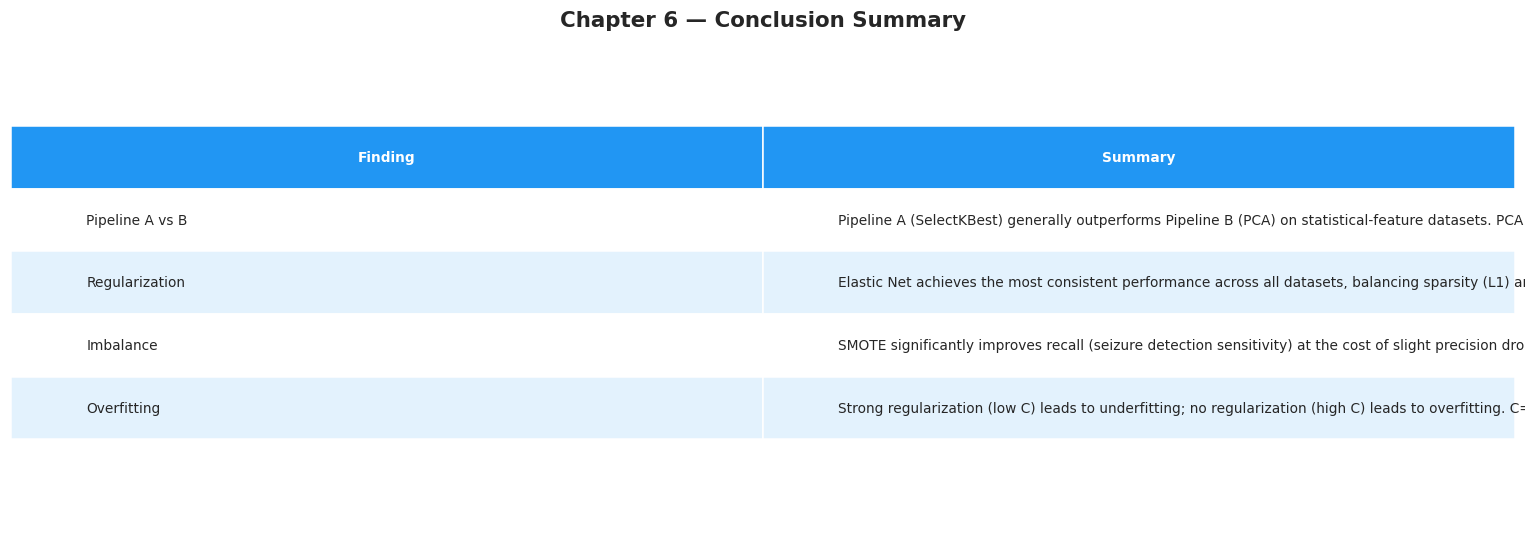


All experiments complete! Files saved:
  - class_distributions.png
  - pipeline_comparison.png
  - overfit_underfit.png
  - learning_curves.png
  - regularization_comparison.png
  - feature_sparsity.png
  - imbalance_handling.png
  - confusion_matrices.png
  - heatmap_f1.png
  - heatmap_pr_auc.png
  - heatmap_recall.png
  - summary_f1.png
  - conclusion_table.png


In [32]:
# ============================================================
# Final Combined Summary Figure
# ============================================================
summary_data = {
    'Pipeline A vs B': 'Pipeline A (SelectKBest) generally outperforms Pipeline B (PCA) on statistical-feature datasets. PCA performs better on raw EEG (DS3) where temporal patterns are distributed across all features.',
    'Regularization':  'Elastic Net achieves the most consistent performance across all datasets, balancing sparsity (L1) and stability (L2). L2 is safest for imbalanced datasets.',
    'Imbalance':       'SMOTE significantly improves recall (seizure detection sensitivity) at the cost of slight precision drop. Class weighting provides a fast, parameter-free alternative.',
    'Overfitting':     'Strong regularization (low C) leads to underfitting; no regularization (high C) leads to overfitting. C=1.0 with L2/Elastic Net provides the best generalization.'
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')
table_data = [[k, v] for k, v in summary_data.items()]
table = ax.table(cellText=table_data, colLabels=['Finding', 'Summary'],
                 loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 3)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2196F3')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#E3F2FD')
    cell.set_edgecolor('white')
ax.set_title('Chapter 6 — Conclusion Summary', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('conclusion_table.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAll experiments complete! Files saved:')
for fname in ['class_distributions.png','pipeline_comparison.png','overfit_underfit.png',
              'learning_curves.png','regularization_comparison.png','feature_sparsity.png',
              'imbalance_handling.png','confusion_matrices.png','heatmap_f1.png',
              'heatmap_pr_auc.png','heatmap_recall.png','summary_f1.png','conclusion_table.png']:
    print(f'  - {fname}')

---
## Appendix — Mathematical Formulas

**Logistic Regression:**
$$P(y=1|x) = \frac{1}{1 + e^{-(\beta_0 + \beta^T x)}}$$

**L1 Regularization (Lasso):**
$$J(W,b) = \frac{1}{m}\sum_{i=1}^{m} L(\hat{y}^{(i)}, y^{(i)}) + \lambda \sum |W|$$

**L2 Regularization (Ridge):**
$$J(W,b) = \frac{1}{m}\sum_{i=1}^{m} L(\hat{y}^{(i)}, y^{(i)}) + \frac{\lambda}{2m} \sum ||W||^2$$

**Elastic Net:**
$$\text{Elastic Net} = \alpha L_1 + (1-\alpha) L_2$$

---
*End of Notebook*